# Предобработка ЭЭГ данных

В этом ноутбуке мы познакомимся поближе с такими темами, как:

- Частота дискретизации и ресемплинг
- Выбор плохих каналов
- Монтаж и референс
- Фильтрация
- Эпохирование и бейзлайн-коррекция

В конце ноутбука будет конспект по всем темам с полезными ссылками для дополнительного чтения

---

### 0. Загрузка данных

In [1]:
!pip install mne==1.11.0 >> None

In [2]:
import mne
import numpy as np
import matplotlib.pyplot as plt
import os

%matplotlib inline

In [3]:
# Путь к sample-датасету (если данных нет, они автоматически скачаются)
sample_data_folder = mne.datasets.sample.data_path()
raw_path = os.path.join(
    sample_data_folder,
    "MEG",
    "sample",
    "sample_audvis_raw.fif",
)

Using default location ~/mne_data for sample...
Creating /root/mne_data


  0%|                                              | 0.00/1.65G [00:00<?, ?B/s]

Untarring contents of '/root/mne_data/MNE-sample-data-processed.tar.gz' to '/root/mne_data'


Attempting to create new mne-python configuration file:
/root/.mne/mne-python.json
Could not read the /root/.mne/mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)
Download complete in 02m16s (1576.2 MB)


Проверим, что данные скачались

In [4]:
raw_path

'/root/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw.fif'

Теперь загрузим сырые данные в объект `Raw`.  
Мы сразу обрежем запись до первых 60 секунд и загрузим её в память (`preload=True`) для ускорения дальнейших операций.


In [5]:
raw = mne.io.read_raw_fif(raw_path, preload=True).crop(tmax=60)

Opening raw data file /root/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.
Reading 0 ... 166799  =      0.000 ...   277.714 secs...


Теперь визуализируем наши данные

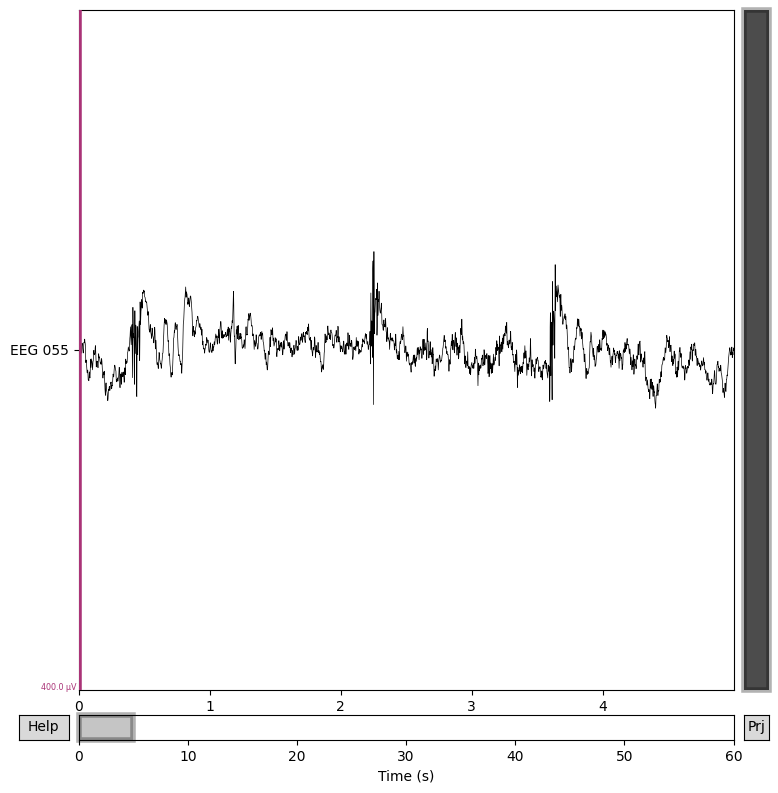

In [9]:
_ = raw.plot(n_channels=2, duration=5.0, picks='EEG 055', scalings=2e-4)

### 1. Частота дискретизации

**Частота (frequency)** – сколько раз волна повторяет полный цикл за секунду. Измеряется в герцах (Гц): 10 Гц = 10 колебаний в секунду.

Период T (время, за которое совершается одно полное колебание) и частота f связаны: T = 1/f сек

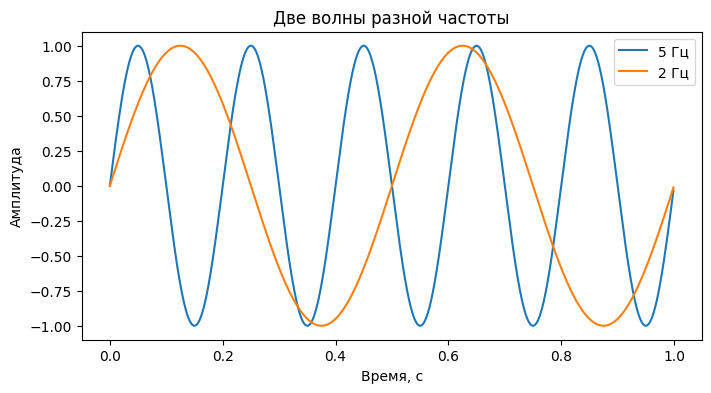

In [7]:
sampling_frequency = 1000
x_time_points = np.arange(0, 1, 1/sampling_frequency)
frequency_1 = 5  # 5 Гц
frequency_2 = 2  # 2 Гц

x1 = np.sin(2 * np.pi * frequency_1 * x_time_points)
x2 = np.sin(2 * np.pi * frequency_2 * x_time_points)

plt.figure(figsize=(8, 4))
plt.plot(x_time_points, x1, label='5 Гц')
plt.plot(x_time_points, x2, label='2 Гц')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')
plt.title('Две волны разной частоты')
plt.legend()
plt.show()

**Амплитуда** — «размах» колебаний: насколько высоко/низко отклоняется волна от нуля. В ЭЭГ обычно измеряется в микровольтах (µV)

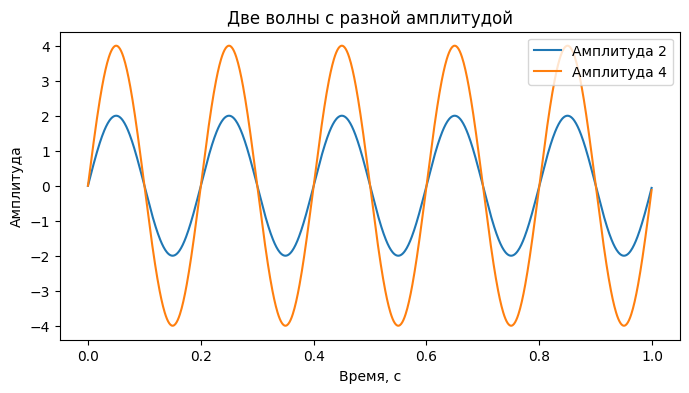

In [8]:
sampling_frequency = 1000
x_time_points = np.arange(0, 1, 1/sampling_frequency)
frequency = 5  # 5 Гц

amplitude_1 = 2
amplitude_2 = 4

x1 = amplitude_1 * np.sin(2 * np.pi * frequency * x_time_points)
x2 = amplitude_2 * np.sin(2 * np.pi * frequency * x_time_points)

plt.figure(figsize=(8, 4))
plt.plot(x_time_points, x1, label='Амплитуда 2')
plt.plot(x_time_points, x2, label='Амплитуда 4')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')
plt.title('Две волны с разной амплитудой')
plt.legend()
plt.show()

**Фаза (phase)** — это «сдвиг» волны по времени, то есть в какой момент цикла мы сейчас. Измеряется в радианах (от 0 до 2π) или в градусах (0–360°).

Две волны с одинаковой частотой, но разной фазой — одинаково «быстрые», но смещены друг относительно друга.

Пример: один и тот же 10 Гц синус, но с разными фазами

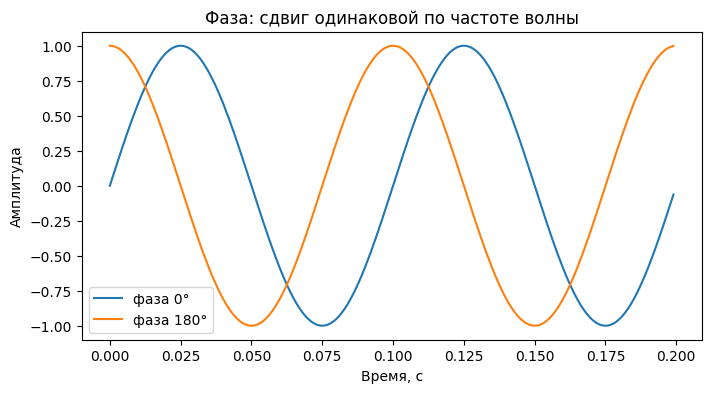

In [10]:
sampling_frequency = 1000
x_time_points = np.arange(0, 0.2, 1/sampling_frequency)
frequency = 10 # 10 Гц

phi1 = 0           # 0°
phi3 = np.pi /2    # 180°

x1 = np.sin(2 * np.pi * frequency * x_time_points + phi1)
x2 = np.sin(2 * np.pi * frequency * x_time_points + phi3)

plt.figure(figsize=(8, 4))
plt.plot(x_time_points, x1, label='фаза 0°')
plt.plot(x_time_points, x2, label='фаза 180°')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')
plt.legend()
plt.title('Фаза: сдвиг одинаковой по частоте волны')
plt.show()

**Частота дискретизации** (sampling frequency) – это количество измерений (сэмплов) аналогового сигнала, производимых за одну секунду при его преобразовании в цифровой формат. Измеряется в Герцах (Гц)

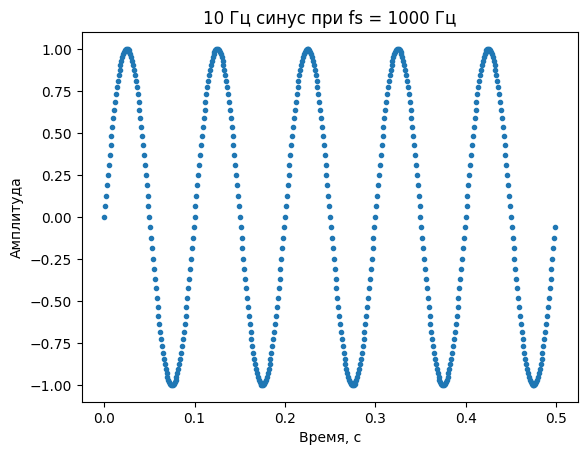

In [11]:
sampling_frequency = 1000 # частота дискретизации, Гц
x_time_points = np.arange(0, 0.5, 1/sampling_frequency) # 0.5 секунды

frequency = 10 # частота синуса, Гц
y_sine = np.sin(2 * np.pi * frequency * x_time_points)

plt.plot('time', 'signal', data={'time': x_time_points, 'signal': y_sine}, marker='.', linestyle='')
#plt.plot(x_time_points, y_sine, '.')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')
plt.title(f'10 Гц синус при fs = {sampling_frequency} Гц')
plt.show()

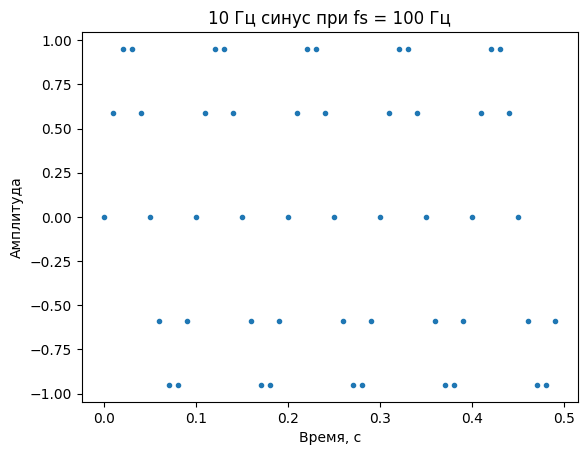

In [12]:
sampling_frequency = 100
x_time_points = np.arange(0, 0.5, 1/sampling_frequency)

y_sine = np.sin(2 * np.pi * frequency * x_time_points)

plt.plot(x_time_points, y_sine, '.')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')
plt.title(f'10 Гц синус при fs = {sampling_frequency} Гц')
plt.show()

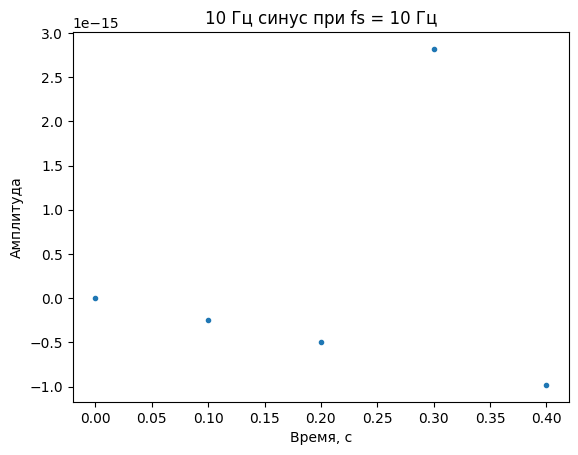

In [13]:
sampling_frequency = 10
x_time_points = np.arange(0, 0.5, 1/sampling_frequency)

y_sine = np.sin(2 * np.pi * frequency * x_time_points)

plt.plot(x_time_points, y_sine, '.')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')
plt.title(f'10 Гц синус при fs = {sampling_frequency} Гц')
plt.show()

**Теорема Найквиста гласит:**

чтобы корректно измерить сигнал, частота дискретизации должна быть как минимум в 2 раза выше, чем максимальная частота, которую вы хотите видеть в сигнале

**Интуиция:**

чтобы правильно «поймать» волну, нужно делать минимум два замера за один её цикл

`raw.info` содержит метаданные: список каналов, частота дискретизации, типы каналов (EEG/MEG/EOG/STIM и т.п.), фильтры, аннотации и др.


In [14]:
raw.info

<Info | 21 non-empty values
 acq_pars: ACQch001 110113 ACQch002 110112 ACQch003 110111 ACQch004 110122 ...
 bads: 2 items (MEG 2443, EEG 053)
 ch_names: MEG 0113, MEG 0112, MEG 0111, MEG 0122, MEG 0123, MEG 0121, MEG ...
 chs: 204 Gradiometers, 102 Magnetometers, 9 Stimulus, 60 EEG, 1 EOG
 custom_ref_applied: False
 description: acquisition (megacq) VectorView system at NMR-MGH
 dev_head_t: MEG device -> head transform
 dig: 146 items (3 Cardinal, 4 HPI, 61 EEG, 78 Extra)
 events: 1 item (list)
 experimenter: MEG
 file_id: 4 items (dict)
 highpass: 0.1 Hz
 hpi_meas: 1 item (list)
 hpi_results: 1 item (list)
 lowpass: 172.2 Hz
 meas_date: 2002-12-03 19:01:10 UTC
 meas_id: 4 items (dict)
 nchan: 376
 proj_id: 1
 proj_name: test
 projs: PCA-v1: off, PCA-v2: off, PCA-v3: off
 sfreq: 600.6 Hz
>

In [15]:
print(f'Исходная частота дискретизации:', raw.info['sfreq'], 'Гц')

Исходная частота дискретизации: 600.614990234375 Гц


#### Полезные ссылки:
- Обзор ЭЭГ как сигнала: https://en.wikipedia.org/wiki/Electroencephalography  
- Про теорему Найквиста: https://habr.com/ru/articles/940396/

### 2. Ресемплинг

**Ресемплинг** — это изменение частоты дискретизации сигнала (сколько отсчётов в секунду мы берём), без повторной записи. В ЭЭГ это делают, чтобы уменьшить размер данных и ускорить анализ, либо чтобы привести разные записи к одной частоте (например, все к 250 Гц)

**Downsampling** — понижение частоты дискретизации, например с 1000 до 250 Гц. При этом теряется часть высокочастотной информации.

**Upsampling** — повышение частоты дискретизации, например с 128 до 200 Гц. Новых реальных данных при этом не появляется, точки интерполируются между существующими

In [16]:
raw_resampled = raw.copy().resample(300, verbose=False)  # downsample до 300 Гц

In [17]:
print('После ресемплинга:', raw_resampled.info['sfreq'], 'Гц')

После ресемплинга: 300.0 Гц


In [20]:
print('До ресемплинга:', raw.info['sfreq'], 'Гц')

До ресемплинга: 600.614990234375 Гц


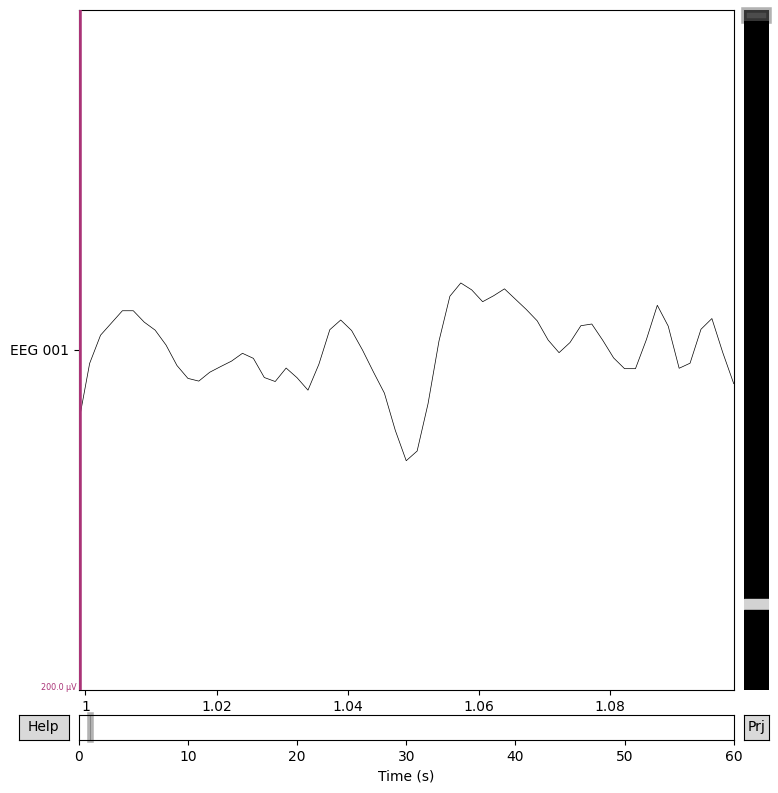

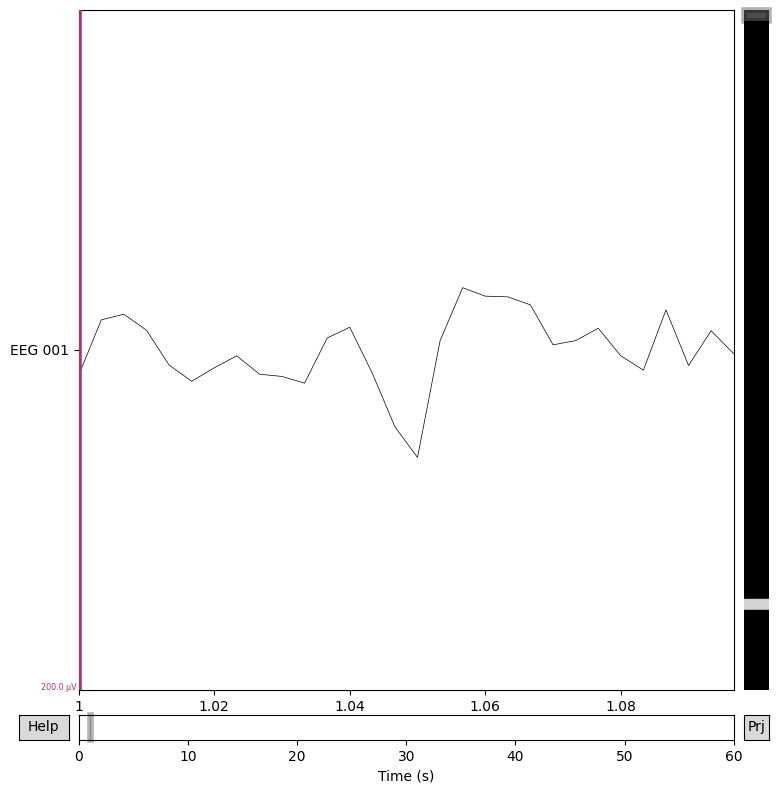

In [19]:
_ = raw.plot(n_channels=1, start=1, duration=0.1, picks='eeg', scalings=1e-4)
_ = raw_resampled.plot(n_channels=1, start=1, duration=0.1, picks='eeg', scalings=1e-4)

#### Полезные ссылки:

- Filtering and resampling data: https://mne.tools/stable/auto_tutorials/preprocessing/30_filtering_resampling.html  
- Функция `mne.filter.resample`: https://mne.tools/stable/generated/mne.filter.resample.html

### 3. Выбор плохих каналов

Иногда отдельные электроды почти не дают полезного сигнала: они сильно шумят или вообще плоские.
В MNE такие каналы не удаляют, а помечают как плохие в списке `info['bads']`. Тогда все последующие функции по умолчанию их игнорируют

In [23]:
raw.info['bads']

['MEG 2443', 'EEG 053']

В окне визуализации можно кликать по имени канала слева, чтобы помечать/снимать пометку «bad» (обычно такие каналы сереют). После того как вы всё отметили, список доступен в `raw.info['bads']`

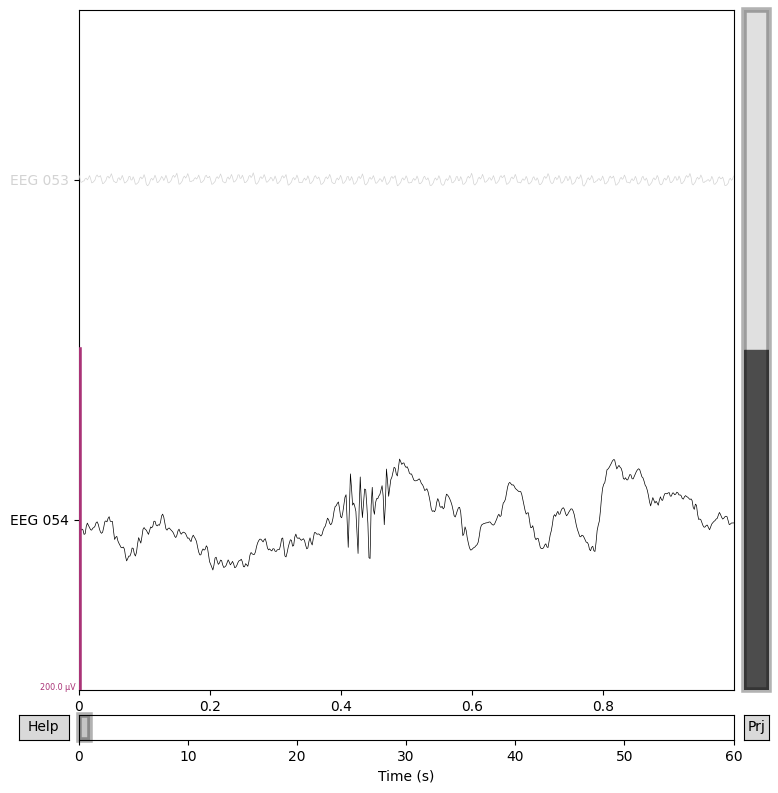

In [25]:
_ = raw.plot(n_channels=2, duration=1.0, picks=['EEG 053','EEG 054'], scalings=1e-4)

Bad‑каналы можно задать и программно c помощью функций:

- `append('MEG 2443')` — добавляет один элемент (строку 'O2') в конец списка.

- `extend(['EEG 053', 'EEG 054'])` — принимает итерируемый объект и добавляет каждый его элемент по отдельности.

In [26]:
raw.info['bads'] = ['MEG 2443', 'EEG 053', 'EEG 054']
# raw.info['bads'] = []
# raw.info['bads'].append('MEG 2443')
# raw.info['bads'].extend(['EEG 053', 'EEG 054'])
# raw.info['bads']

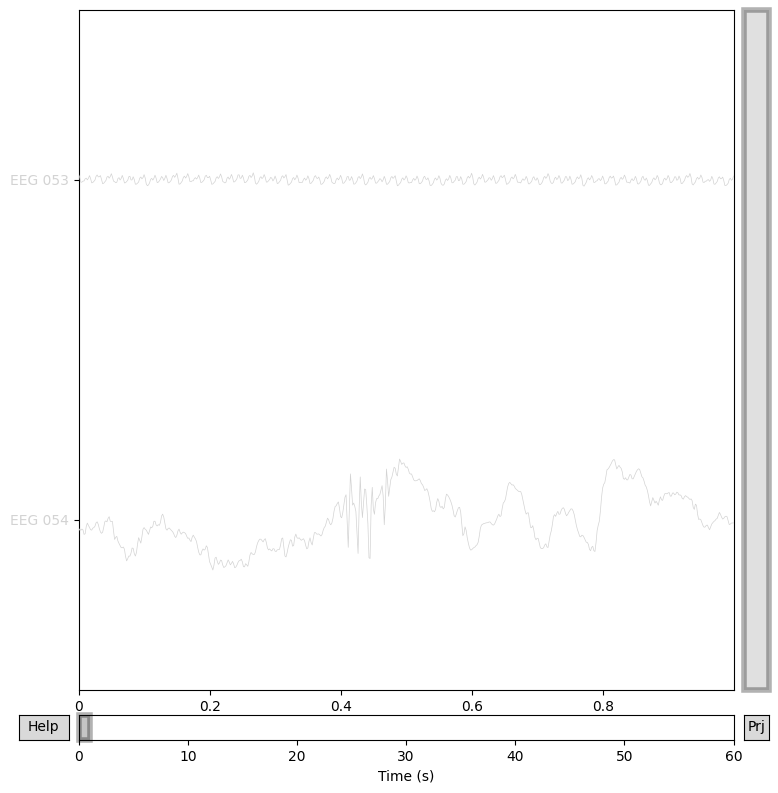

In [27]:
_ = raw.plot(n_channels=2, duration=1.0, picks=['EEG 053','EEG 054'], scalings=1e-4)

In [ ]:
_ = raw.plot(n_channels=2, duration=5.0, picks=['EEG 053','EEG 054'], scalings=1e-4)

Помимо удаления каналов - можно использовать интерполяцию bad‑каналов, где сигнал пытаемся восстановить по соседним «хорошим» каналам. MNE использует для этого специальные алгоритмы

Когда это полезно:

1) Вам нужно одинаковое число каналов у всех испытуемых

2) Потерять канал жалко, а соседи дают надёжный сигнал.

Когда не стоит интерполировать:

1) Если плохих каналов слишком много — интерполяция будет ненадёжной, лучше задуматься о качестве записи.

2) Интерполированный канал не несёт новой информации, а лишь усредняет соседей



Setting channel interpolation method to {'meg': 'MNE'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 91.2 mm
    Computing dot products for 203 MEG channels...
    Computing cross products for 203 → 1 MEG channel...
    Preparing the mapping matrix...
    Truncating at 84/203 components to omit less than 0.0001 (9.7e-05)


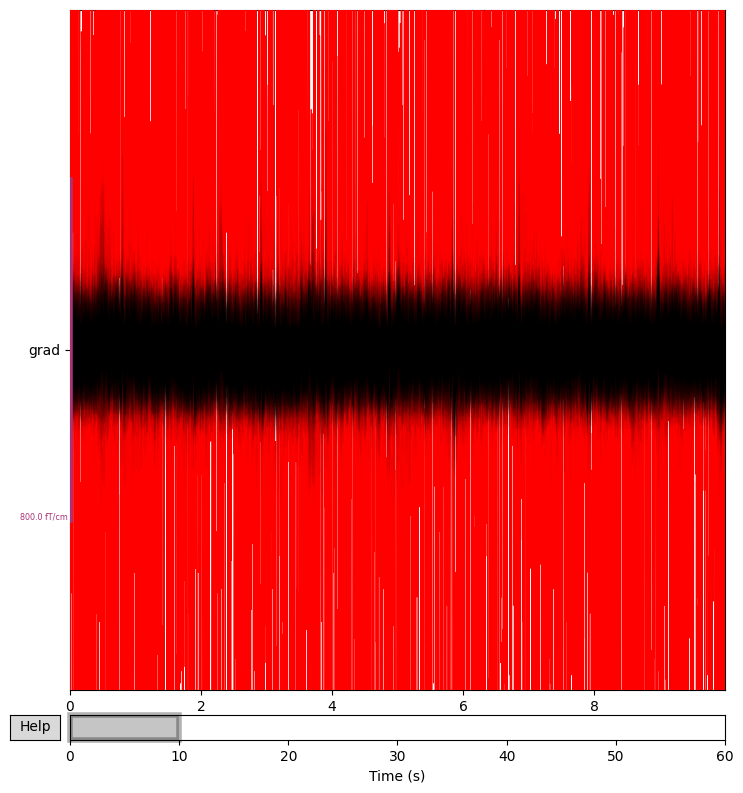

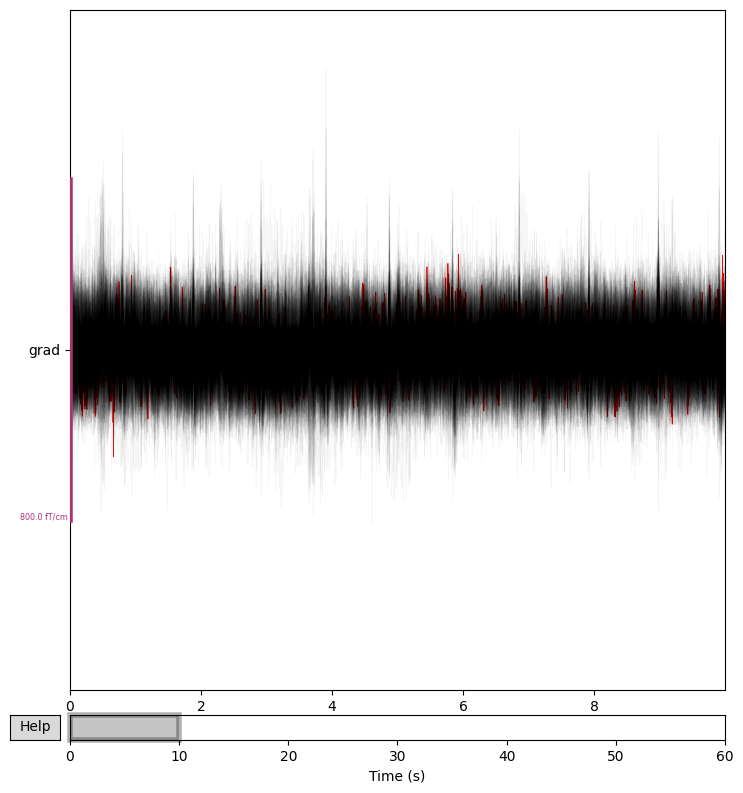

In [28]:
grad_data = raw.copy().pick(picks="grad")
grad_data_interp = grad_data.copy().interpolate_bads(reset_bads=False)

for data in (grad_data, grad_data_interp):
    data.plot(butterfly=True, color="#00000009", bad_color="r") # butterfly - изобразить все каналы поверх друг друга

#### Полезные ссылки:  

- Handling bad channels: https://mne.tools/stable/auto_tutorials/preprocessing/15_handling_bad_channels.html   

### 4. Монтаж и референс

В ЭЭГ нам важно знать где расположены электроды на голове (монтаж) и относительно какой точки измеряется напряжение (референс)

Монтаж задаёт 3D‑координаты электродов (например, стандартная система 10–20). В MNE это делается так

4 duplicate electrode labels found:
T7/T3, T8/T4, P7/T5, P8/T6
Plotting 90 unique labels.


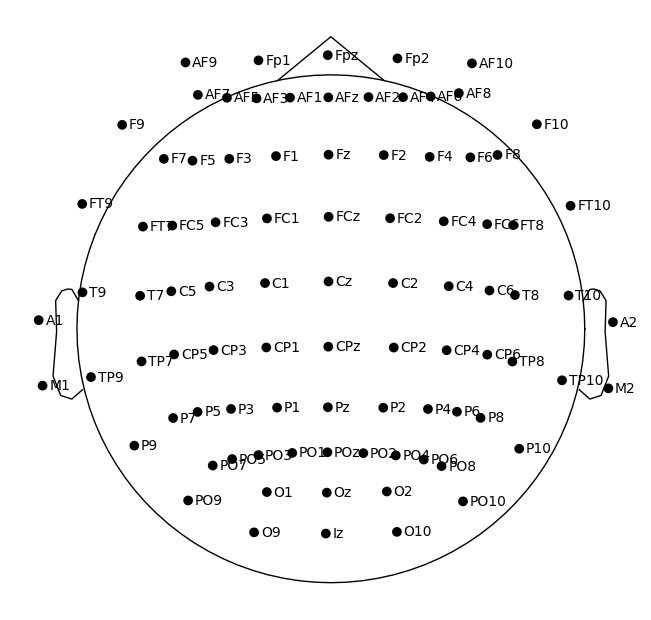

In [29]:
# загружаем стандартный монтаж 10-20
montage = mne.channels.make_standard_montage('standard_1020')
_ = montage.plot(show_names=True)

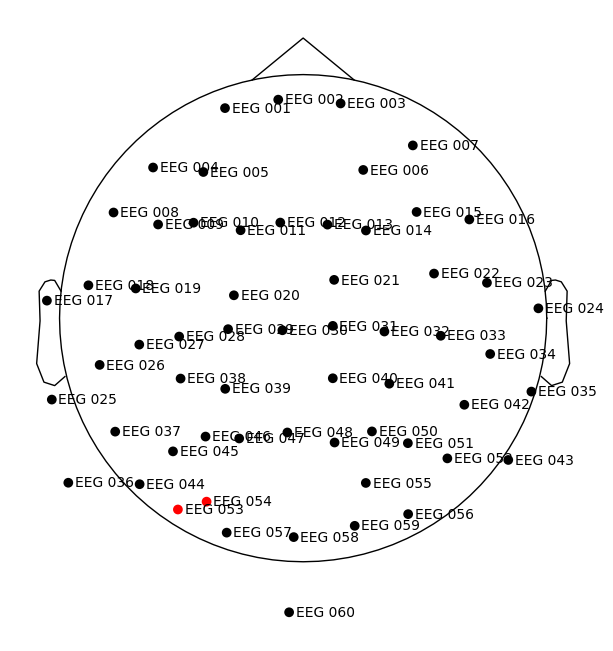

In [30]:
# raw.set_montage(montage)

# проверяем, изборажаем топологию (карту) каналов
_ = raw.plot_sensors(ch_type='eeg', show_names=True)

In [31]:
from mne.channels import get_builtin_montages

# просто имена всех встроенных монтажей
names = get_builtin_montages()
print(names[:5]) # используем срезы

['standard_1005', 'standard_1020', 'standard_alphabetic', 'standard_postfixed', 'standard_prefixed']


In [32]:
names_desc = get_builtin_montages(descriptions=True)
for name, desc in names_desc[:3]: #итерируемся по парам имя - описание
    print(name, ":", desc, '\n')

standard_1005 : Electrodes are named and positioned according to the international 10-05 system (343+3 locations) 

standard_1020 : Electrodes are named and positioned according to the international 10-20 system (94+3 locations) 

standard_alphabetic : Electrodes are named with LETTER-NUMBER combinations (A1, B2, F4, …) (65+3 locations) 



ЭЭГ всегда измеряется относительно какой‑то точки (референса). Меняя референс, мы меняем «точку отсчёта» и тем самым форму сигналов

**Самые базовые варианты в MNE:**

1. Средний референс (common average reference)
Каждый канал вычитается со средней по всем EEG‑каналам

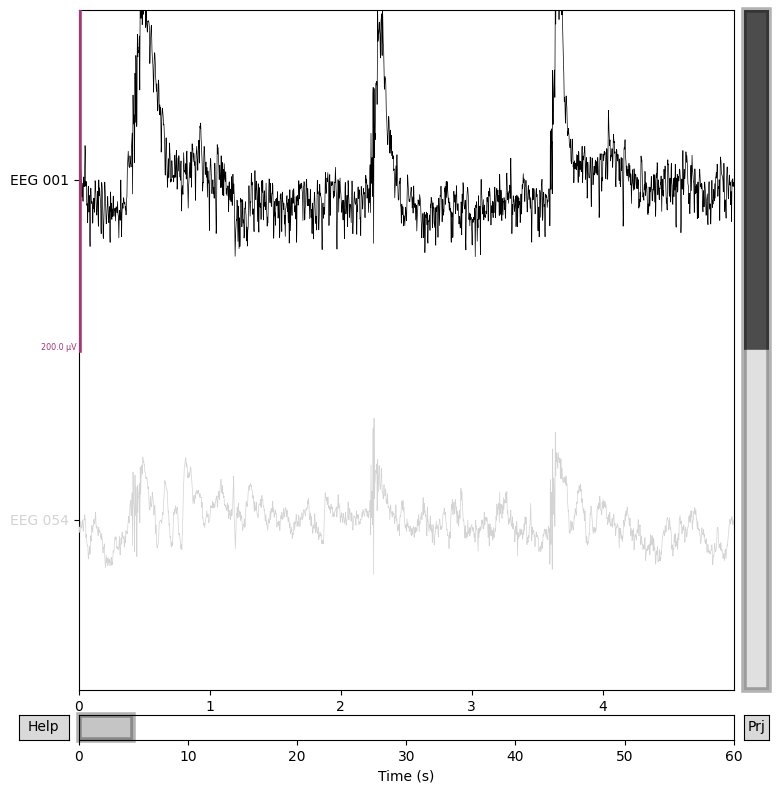

In [33]:
_ = raw.plot(n_channels=2, duration=5.0, picks=['EEG 001','EEG 054'], scalings=1e-4)

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Created an SSP operator (subspace dimension = 3)


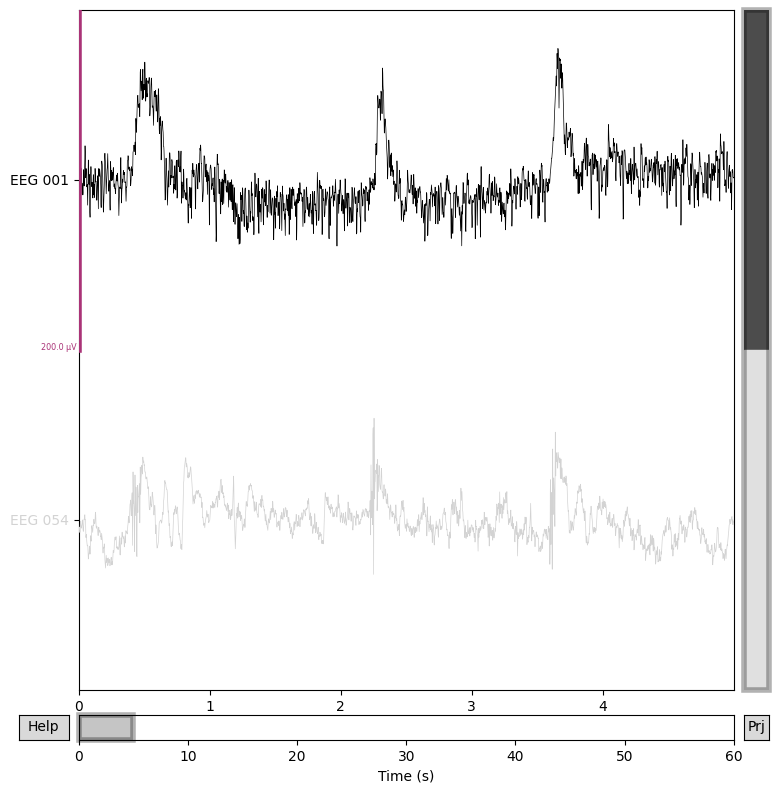

In [34]:
# ставим средний референс для всех EEG-каналов
raw_car = raw.copy().set_eeg_reference("average")
_ = raw_car.plot(n_channels=2, duration=5.0, picks=['EEG 001','EEG 054'], scalings=1e-4)

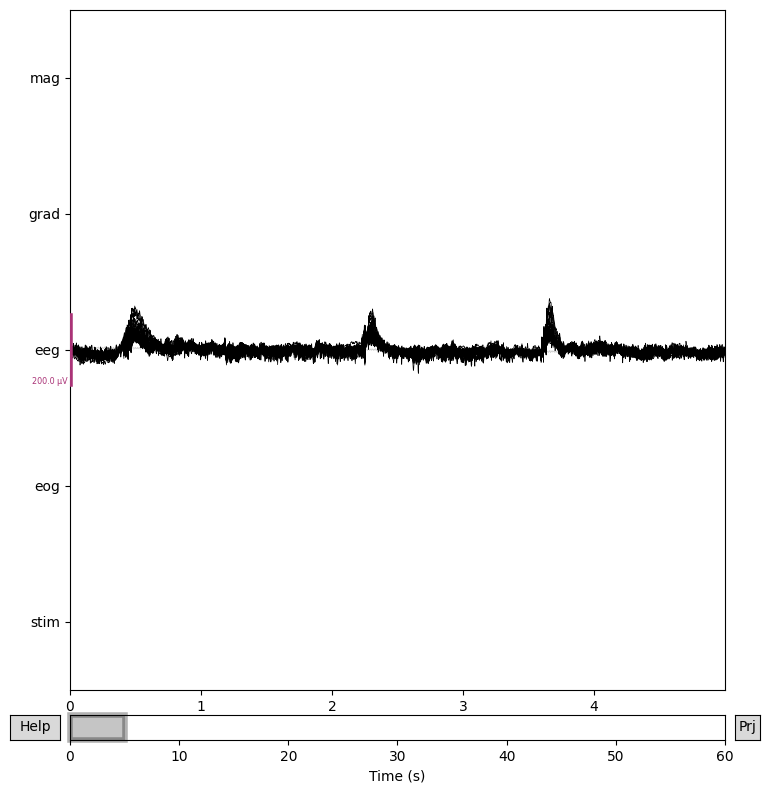

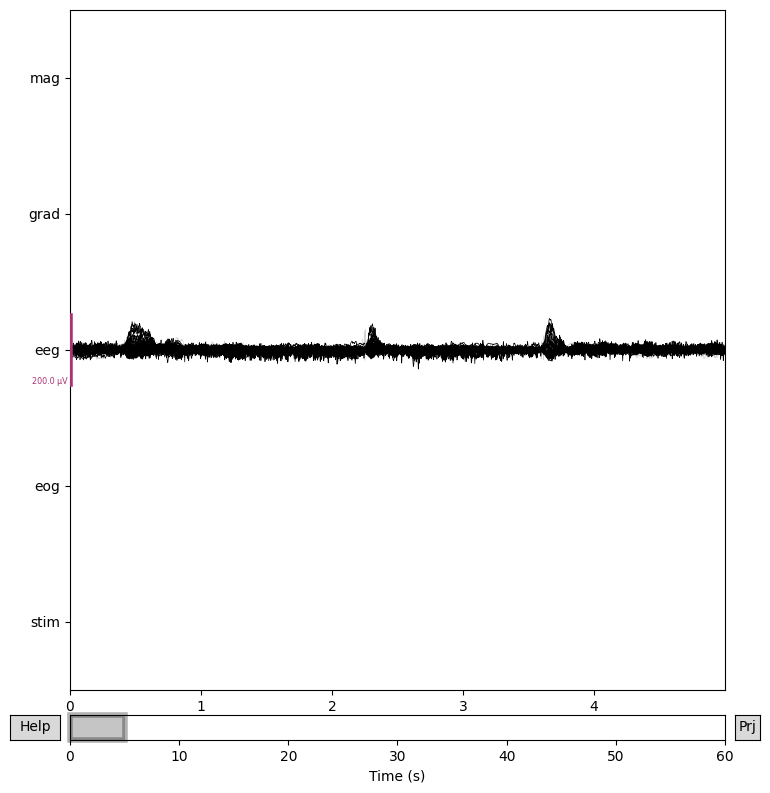

In [35]:
_ = raw.plot(butterfly=True, duration=5.0, scalings=1e-4, picks='eeg')
_ = raw_car.plot(butterfly=True, duration=5.0, scalings=1e-4, picks='eeg')

2. Референс по конкретным электродам

Например, использовать как референс клипсы на ушах. Тогда все остальные EEG‑каналы будут выражены «относительно ушей»

EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Created an SSP operator (subspace dimension = 3)


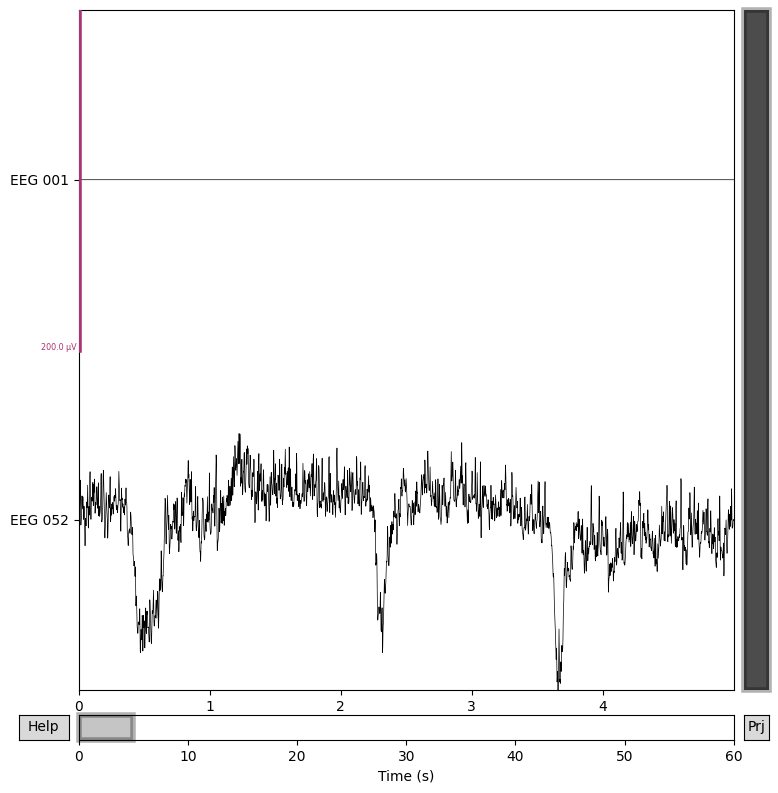

In [37]:
raw_eeg001 = raw.copy().set_eeg_reference(ref_channels=['EEG 001'])
_ = raw_eeg001.plot(n_channels=2, duration=5.0, picks=['EEG 001','EEG 052'], scalings=1e-4)

EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Created an SSP operator (subspace dimension = 3)


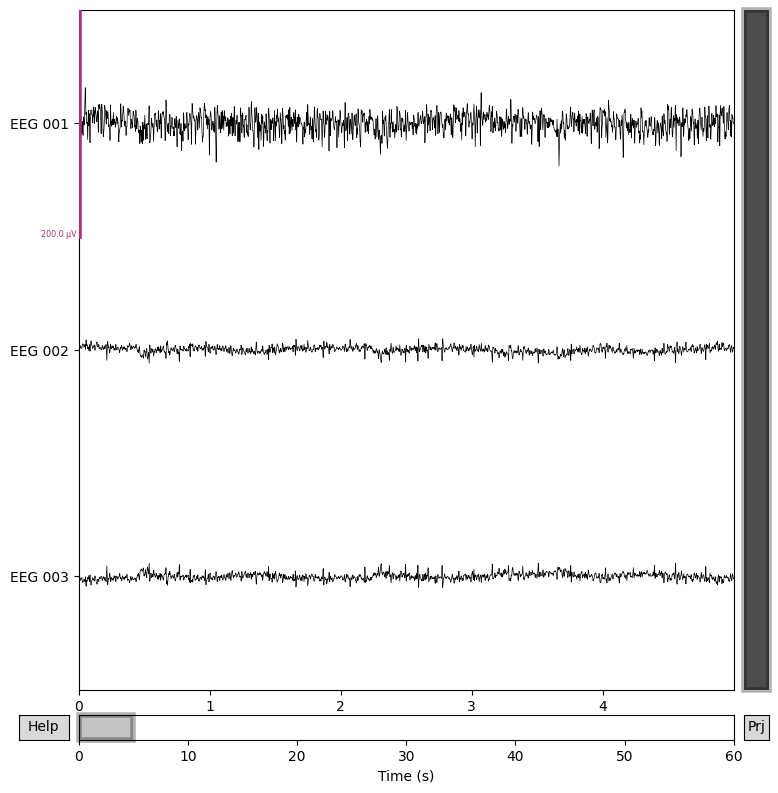

In [38]:
raw_eeg001 = raw.copy().set_eeg_reference(ref_channels=['EEG 002', 'EEG 003'])
_ = raw_eeg001.plot(n_channels=3, duration=5.0, picks=['EEG 001','EEG 002', 'EEG 003'], scalings=1e-4)

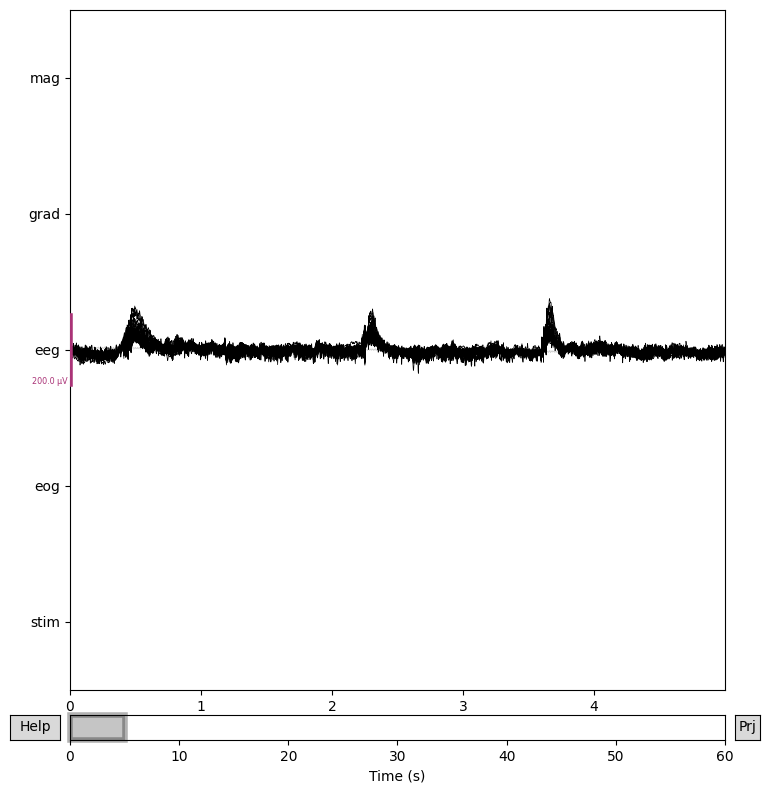

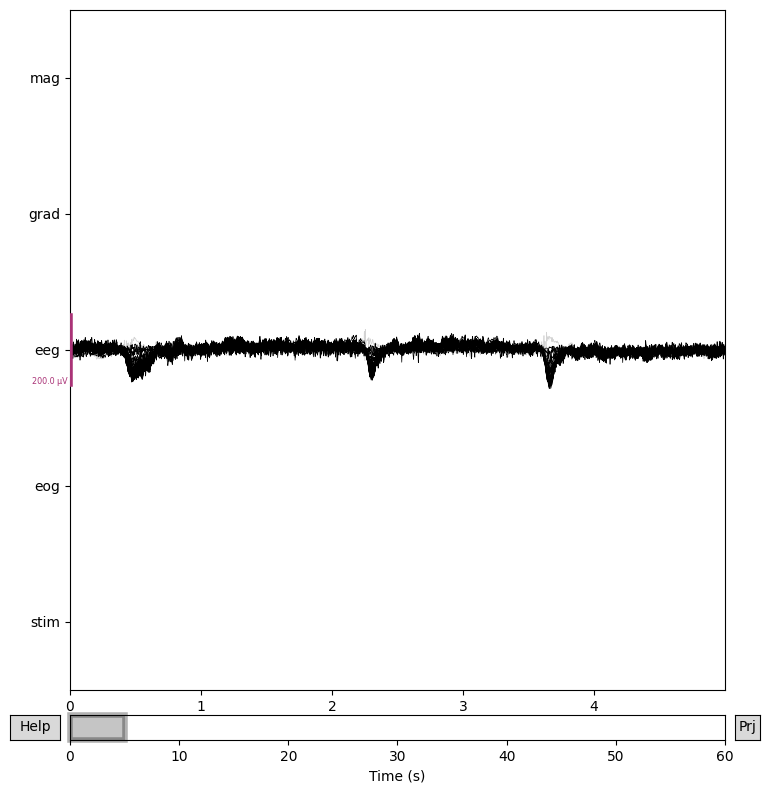

In [39]:
_ = raw.plot(butterfly=True, duration=5.0, scalings=1e-4, picks='eeg')
_ = raw_eeg001.plot(butterfly=True, duration=5.0, scalings=1e-4, picks='eeg')

#### Полезные ссылки:  
- Монтаж ЭЭГ 10-20: https://cmi.to/ээг/система-10-20/
- Расположение сенсоров и монтажи: https://mne.tools/stable/auto_tutorials/intro/40_sensor_locations.html  
- Список встроенных монтажей: https://mne.tools/stable/generated/mne.channels.get_builtin_montages.html  
- Ставим ЭЭГ референс: https://mne.tools/stable/auto_tutorials/preprocessing/55_setting_eeg_reference.html  

### 5. Фильтрация

In [40]:
raw.info

<Info | 21 non-empty values
 acq_pars: ACQch001 110113 ACQch002 110112 ACQch003 110111 ACQch004 110122 ...
 bads: 3 items (MEG 2443, EEG 053, EEG 054)
 ch_names: MEG 0113, MEG 0112, MEG 0111, MEG 0122, MEG 0123, MEG 0121, MEG ...
 chs: 204 Gradiometers, 102 Magnetometers, 9 Stimulus, 60 EEG, 1 EOG
 custom_ref_applied: False
 description: acquisition (megacq) VectorView system at NMR-MGH
 dev_head_t: MEG device -> head transform
 dig: 146 items (3 Cardinal, 4 HPI, 61 EEG, 78 Extra)
 events: 1 item (list)
 experimenter: MEG
 file_id: 4 items (dict)
 highpass: 0.1 Hz
 hpi_meas: 1 item (list)
 hpi_results: 1 item (list)
 lowpass: 172.2 Hz
 meas_date: 2002-12-03 19:01:10 UTC
 meas_id: 4 items (dict)
 nchan: 376
 proj_id: 1
 proj_name: test
 projs: PCA-v1: off, PCA-v2: off, PCA-v3: off
 sfreq: 600.6 Hz
>

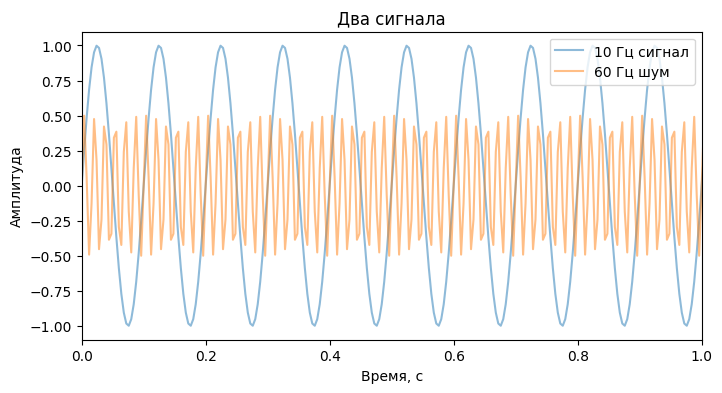

In [41]:
from scipy.signal import butter, filtfilt

fs = 250  # частота дискретизации, Гц
t = np.arange(0, 2.0, 1/fs)

# сигнал = полезный 10 Гц синус + высокочастотный шум 60 Гц
x_clean = np.sin(2 * np.pi * 10 * t)
x_noise = 0.5 * np.sin(2 * np.pi * 60 * t)
x = x_clean + x_noise

plt.figure(figsize=(8, 4))
plt.plot(t, x_clean, label="10 Гц сигнал", alpha=0.5)
plt.plot(t, x_noise, label="60 Гц шум", alpha=0.5)
plt.xlim(0, 1.0)
plt.xlabel("Время, с")
plt.ylabel("Амплитуда")
plt.legend()
plt.title("Два сигнала")
plt.show()

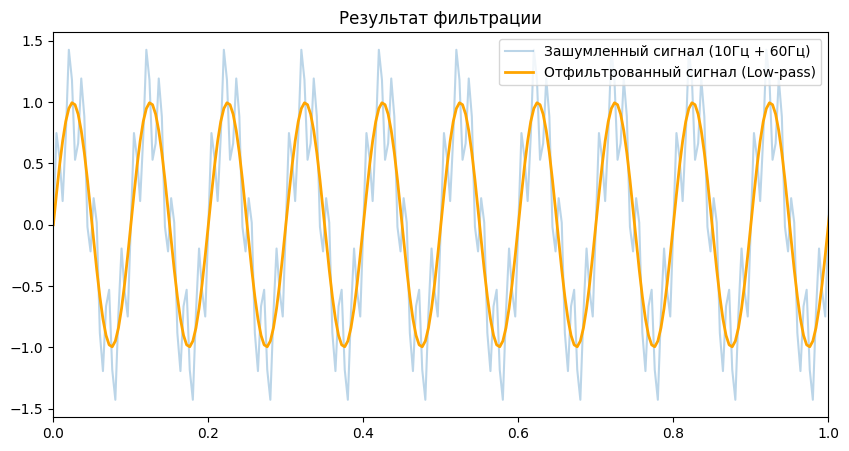

In [42]:
cutoff = 20  # частота среза, Гц (пропускаем всё, что ниже 20 Гц)
nyq = 0.5 * fs  # частота Найквиста
normal_cutoff = cutoff / nyq
order = 4  # порядок фильтра

b, a = butter(order, normal_cutoff, btype='low', analog=False)

y = filtfilt(b, a, x)

plt.figure(figsize=(10, 5))
plt.plot(t, x, label='Зашумленный сигнал (10Гц + 60Гц)', alpha=0.3)
plt.plot(t, y, label='Отфильтрованный сигнал (Low-pass)', color='orange', linewidth=2)
plt.xlim(0, 1)
plt.legend()
plt.title("Результат фильтрации")
plt.show()

Filtering a subset of channels. The highpass and lowpass values in the measurement info will not be updated.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1983 samples (3.302 s)



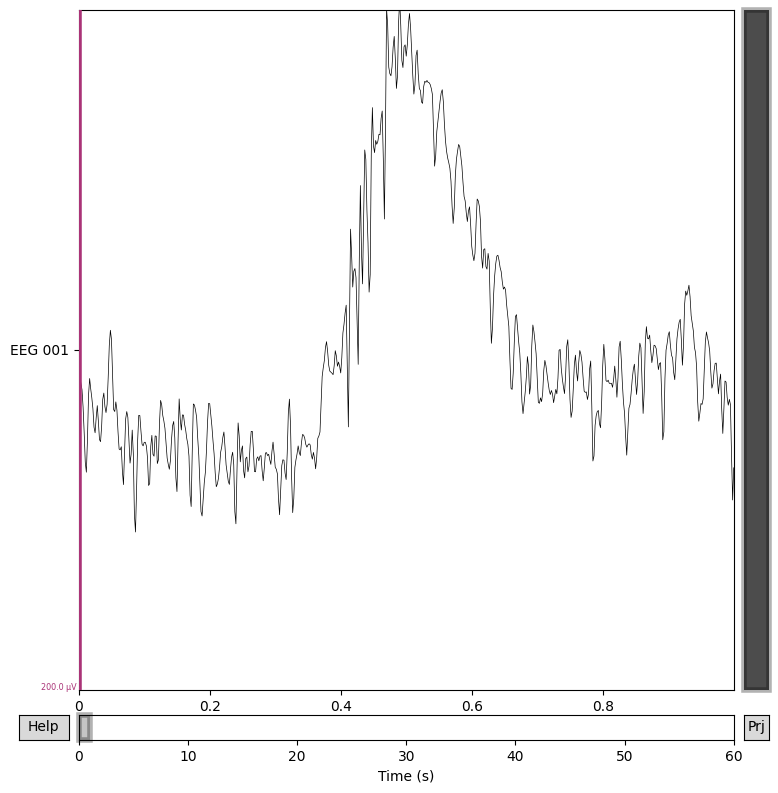

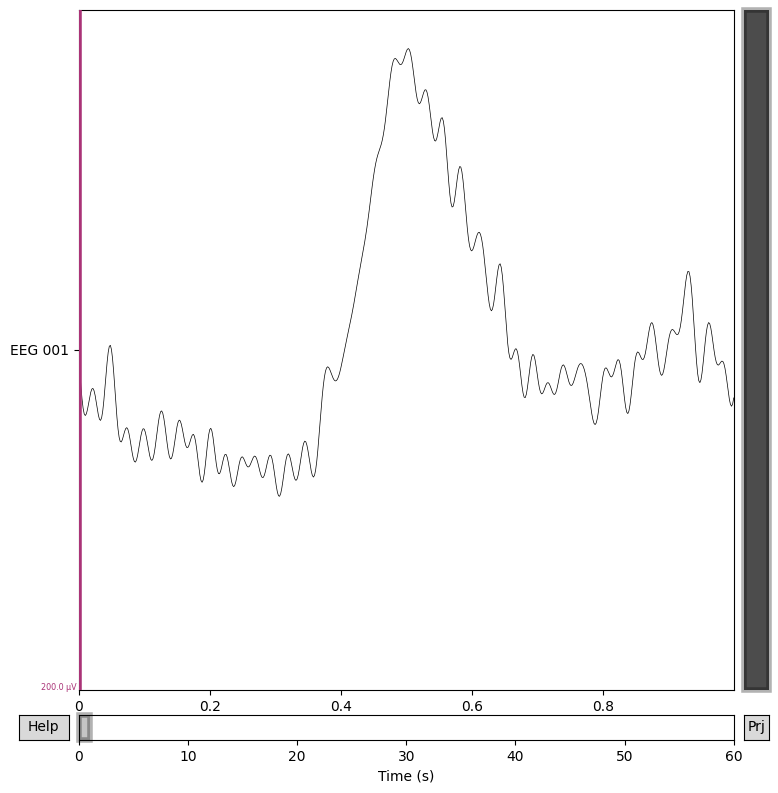

In [45]:
# полосовой фильтр 1–40 Гц
raw_filt = raw.copy().filter(
    l_freq=1.0,    # нижняя граница (high-pass)
    h_freq=40.0,   # верхняя граница (low-pass)
    picks="eeg"    # фильтруем только EEG-каналы
)

# сравним до/после визуально
_ = raw.plot(n_channels=2, duration=1.0, picks=['EEG 001'], scalings=1e-4)
_ = raw_filt.plot(n_channels=2, duration=1.0, picks=['EEG 001'], scalings=1e-4)


Effective window size : 3.410 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


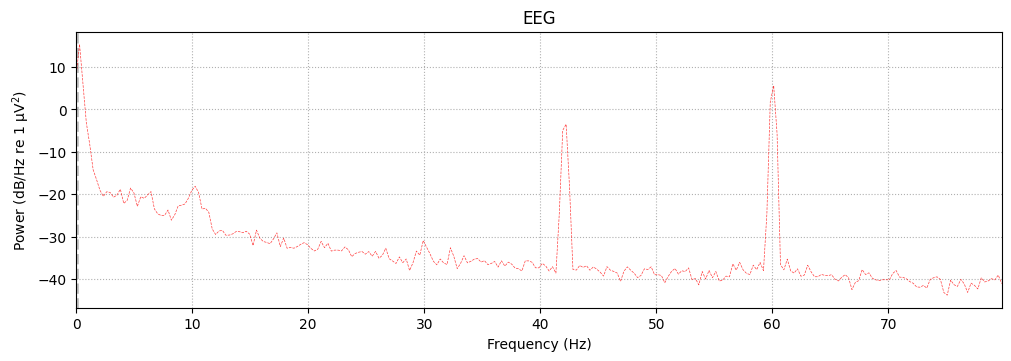

In [47]:
_ = raw.compute_psd(fmax=80).plot(picks="EEG 053")

Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 3965 samples (6.602 s)

Effective window size : 3.410 (s)
Plotting power spectral density (dB=True).
Effective window size : 3.410 (s)
Plotting power spectral density (dB=True).


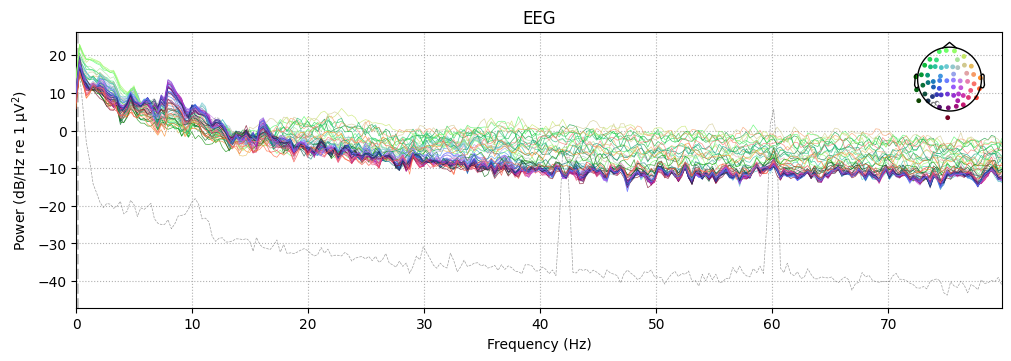

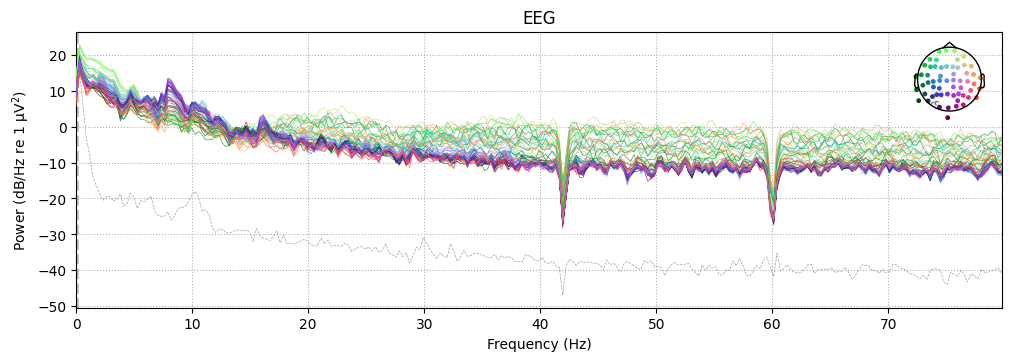

In [48]:
raw_notch = raw.copy().notch_filter(
    freqs=[42, 60],
    picks="eeg"
)

# оценим спектр до/после
_ = raw.compute_psd(fmax=80).plot(picks="eeg")
_ = raw_notch.compute_psd(fmax=80).plot(picks="eeg")

Мини‑резюме:

Фильтр работает как «частотный кран»: открываем полезный диапазон (например, 1–40 Гц), закрываем остальное.

В `scipy` это делается через `butter` + `filtfilt`, в `MNE` — через `raw.filter()` и `raw.notch_filter()`, уже оптимизированные под ЭЭГ.

Фильтрацию лучше применять после разметки bad‑каналов и установки референса, но до ресемплинга

#### Полезные ссылки:  
- По поводу фильтрации: https://mne.tools/stable/auto_tutorials/preprocessing/25_background_filtering.html
- Туториал по фильтрации: https://mne.tools/stable/auto_tutorials/preprocessing/30_filtering_resampling.html  
- Функция `mne.filter.filter_data`: https://mne.tools/stable/generated/mne.filter.filter_data.html  

### 6. Эпохирование и бейзлайн-коррекция

Сырой ЭЭГ‑сигнал — это длинная непрерывная запись. При экспериментах со стимулами нас интересует, что происходит вокруг каждого стимула: до него и после него

Для этого мы режем `Raw` на короткие куски, засинхроненные по времени с событием — эти куски и называются эпохами (epochs)

In [50]:
events = mne.find_events(raw, stim_channel="STI 014")
print(events[:5])

Finding events on: STI 014
86 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]
[[27977     0     2]
 [28345     0     3]
 [28771     0     1]
 [29219     0     4]
 [29652     0     2]]


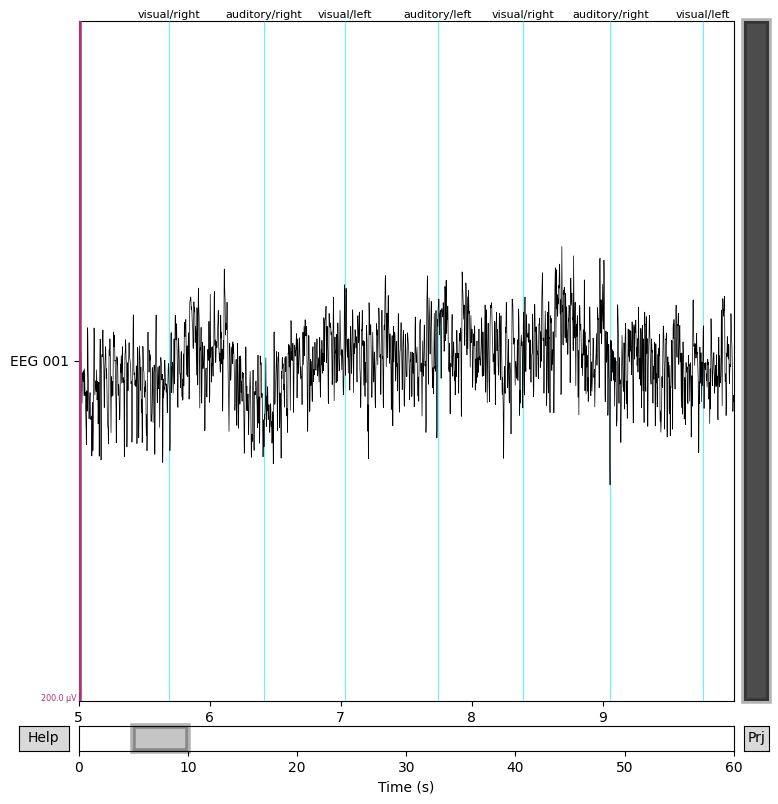

In [51]:
# словарь кодов событий (пример для sample-дата)
event_id = {
    "auditory/left": 1,
    "auditory/right": 2,
    "visual/left": 3,
    "visual/right": 4,
}

# рисуем raw с вертикальными линиями-событиями
_ = raw.plot(n_channels=2, start=5.0, duration=5.0, picks=['EEG 001'], scalings=1e-4, events=events, event_id=event_id)

Зачем нужна baseline‑коррекция

ЭЭГ в разных каналах при разных стимулах может иметь смещённый уровень сигнала. Baseline‑коррекция помогает этого избежать:

- Берём предстимульный интервал (за 0.2 сек до стимула до самого момента стимула)
- Считаем среднее значение сигнала в этом интервале
- Вычитаем это среднее из всей эпохи

В результате к моменту 0 с среднее значение становится ровно 0, а все эпохи лучше сравниваются между собой

In [52]:
epochs = mne.Epochs(
    raw,
    events=events,
    event_id=event_id,
    tmin=-0.2,
    tmax=0.5,
    baseline=(-0.2, 0),  # от начала эпохи до 0 с
    preload=True,
)

Not setting metadata
78 matching events found
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 3)
3 projection items activated
Using data from preloaded Raw for 78 events and 421 original time points ...
0 bad epochs dropped


In [53]:
# отдельные Evoked-объекты для каждого события
evoked_aud_l = epochs["auditory/left"].average()
evoked_aud_r = epochs["auditory/right"].average()


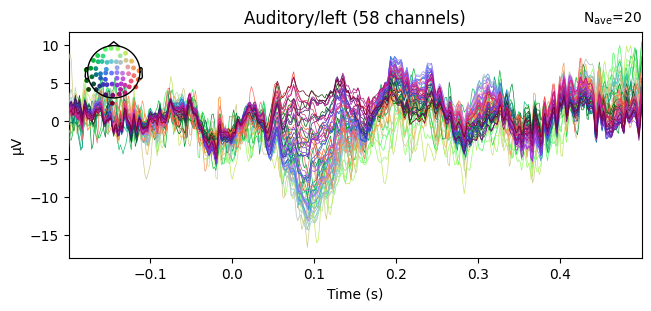

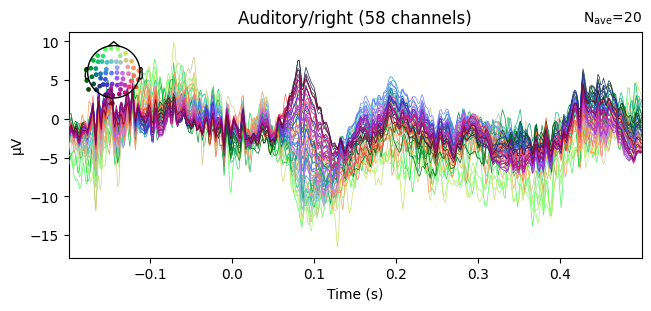

In [54]:
_ = evoked_aud_l.plot(picks='eeg', titles="Auditory/left")
_ = evoked_aud_r.plot(picks='eeg', titles="Auditory/right")

combining channels using "mean"
combining channels using "mean"


/tmp/ipykernel_3830/1362479616.py:1: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(


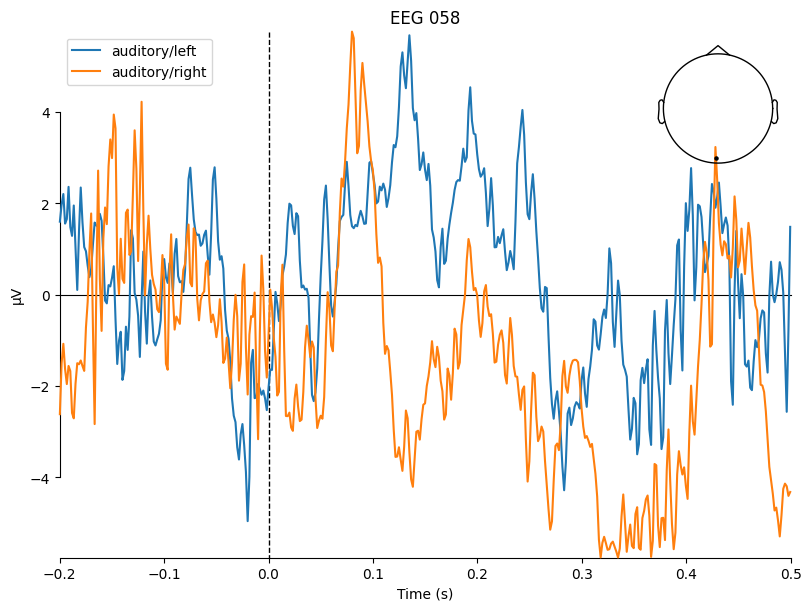

[<Figure size 800x600 with 2 Axes>]

In [55]:
mne.viz.plot_compare_evokeds(
    {"auditory/left": evoked_aud_l, "auditory/right": evoked_aud_r},
    picks="EEG 058",
    combine="mean",
)

Лучше сделать ДО Epochs:

- пометить bad‑каналы и, при необходимости, интерполировать их
- поставить монтаж и референс (часто средний)
- отфильтровать сигнал (high‑pass, low‑pass, notch)

На этапе Epochs / ПОСЛЕ:

- сделать ресемплинг (уменьшить для ускорения)
- cделать baseline‑коррекцию (обычно (None, 0))
- отбросить очень шумные эпохи (по амплитудному порогу или вручную)
- усреднять эпохи, и уже их использовать для дальнейшего анализа

#### Полезные ссылки:  
- Про эпохи: https://mne.tools/stable/auto_tutorials/epochs/10_epochs_overview.html  
- Визуализация эпох: https://mne.tools/stable/auto_tutorials/epochs/20_visualize_epochs.html  
- ERP overview: https://mne.tools/stable/auto_tutorials/evoked/10_evoked_overview.html

---

## Небольшой конспект по ноутбуку «Предобработка ЭЭГ данных»

---

### 1. Частота дискретизации и ресемплинг

- частота — сколько циклов в секунду (Гц), связана с периодом как \(T = 1/f\);
- амплитуда — размах колебаний относительно нуля;
- фаза — сдвиг волны по времени при одинаковой частоте.

Частота дискретизации (sfreq) задаёт, сколько отсчётов в секунду содержит сигнал; в MNE хранится как `raw.info['sfreq']`

#### Примеры использования:
```
print(raw.info['sfreq']) # print sampling frequency
```

Теорема Найквиста: чтобы корректно оцифровать сигнал с максимальной частотой $f_{max}$, частота дискретизации должна быть ≥ 2·$f_{max}$  

Ресемплинг — изменение частоты дискретизации без повторной записи: downsampling уменьшает размер и скорость обработки, upsampling добавляет интерполированные точки, но не новые данные.

До downsampling желательно отфильтровать высокочастотные компоненты, чтобы избежать алиасинга.

Важно помнить про события: при ресемплинге нужно корректно пересчитать их временные метки

#### Примеры использования:
```
raw_resampled = raw.copy().resample(250) # resample to 250 Hz
```

#### Полезные ссылки:
- Обзор ЭЭГ как сигнала: https://en.wikipedia.org/wiki/Electroencephalography  
- Про теорему Найквиста: https://habr.com/ru/articles/940396/
- Filtering and resampling data: https://mne.tools/stable/auto_tutorials/preprocessing/30_filtering_resampling.html  
- Функция `mne.filter.resample`: https://mne.tools/stable/generated/mne.filter.resample.html  

---

### 2. Выбор плохих каналов

Плохие каналы — электроды с очевидными проблемами (сильный шум, постоянный дрейф, обрыв контакта, «плоская линия»).

В MNE их не удаляют, а помечают в `raw.info['bads']`; большинство функций по умолчанию их игнорируют.

Выделять bad‑каналы можно визуально (через `raw.plot`) и/или программно (по амплитуде, дисперсии, корреляции).

Интерполяция bad‑каналов восстанавливает сигнал по соседним хорошим каналам; это полезно для сохранения одинакового числа каналов, но не создаёт новой информации

#### Примеры использования:
```
# add manually
raw.info['bads'] = ['MEG 2443', 'EEG 053']
# or interpolate
raw_interp = raw.copy().interpolate_bads(reset_bads=True)
```

#### Полезные ссылки:  
- Handling bad channels: https://mne.tools/stable/auto_tutorials/preprocessing/15_handling_bad_channels.html   

---

### 3. Монтаж и референс

Монтаж описывает топологию ЭЭГ: трёхмерные координаты электродов и их расположение на голове (например, система 10–20).

Правильно заданный монтаж нужен для топографий, интерполяции, источникового моделирования и сравнения данных между испытуемыми.

#### Примеры использования:
```
montage = mne.channels.make_standard_montage('standard_1020')
montage.plot(show_names=True)
```

Референс — точка отсчёта для измерения потенциалов; выбор референса влияет на форму сигналов, но не на относительные различия во времени.

Базовые референсы: средний (common average), конкретные электроды (уши, мастоиды), или референс, заданный оборудованием.

#### Примеры использования:
```
raw_car = raw.copy().set_eeg_reference("average")
# OR
raw_ref = raw.copy().set_eeg_reference(ref_channels=['EEG 001'])
```

#### Полезные ссылки:  
- Монтаж ЭЭГ 10-20: https://cmi.to/ээг/система-10-20/
- Расположение сенсоров и монтажи: https://mne.tools/stable/auto_tutorials/intro/40_sensor_locations.html  
- Список встроенных монтажей: https://mne.tools/stable/generated/mne.channels.get_builtin_montages.html  
- Ставим ЭЭГ референс: https://mne.tools/stable/auto_tutorials/preprocessing/55_setting_eeg_reference.html  

---

### 4. Фильтрация

Фильтрация — подавление одних частот и сохранение других; помогает убрать дрейф (очень низкие частоты), мышечный шум (высокие частоты), сетевую помеху (узкая полоса).

High‑pass (l_freq>0) удаляет низкие частоты, low‑pass (h_freq<Nyquist_frequency) удаляет высокие частоты, band‑pass — комбинация, notch подавляет узкую полосу вокруг заданной частоты.

В контексте ЭЭГ типичный диапазон интереса — 1–40 Гц (но зависит от задачи)

В MNE реализованы продуманные фильтры по умолчанию, поэтому лучше использовать `raw.filter` и `raw.notch_filter`, а не собирать всё вручную

#### Примеры использования:
```
raw_filt = raw.copy().filter(l_freq=1.0, h_freq=40.0, picks="eeg")
raw_notch = raw.copy().notch_filter(freqs=[50], picks="eeg")
```

#### Полезные ссылки:  
- По поводу фильтрации: https://mne.tools/stable/auto_tutorials/preprocessing/25_background_filtering.html
- Туториал по фильтрации: https://mne.tools/stable/auto_tutorials/preprocessing/30_filtering_resampling.html  
- Функция `mne.filter.filter_data`: https://mne.tools/stable/generated/mne.filter.filter_data.html  

---

### 5. Эпохирование и baseline‑коррекция

Эпохи — короткие отрезки сигнала, вырезанные вокруг событий (стимулов): от $t_{min}$ до $t_{max}$ относительно триггера.

Epochs позволяют сравнивать реакции на повторяющиеся события, усреднять их и получать потенциальные вызванные ответы (ERPs/evoked).

Baseline‑коррекция компенсирует смещение уровня и дрейф: из каждой эпохи вычитается среднее значение сигнала в выбранном «нейтральном» интервале (часто до стимула)  

#### Рекомендуемый порядок шагов предобработки

1. Загрузка Raw, проверка `raw.info`, базовая визуализация.  
2. Пометка bad‑каналов и (опционально) интерполяция.  
3. Установка корректного монтажа и референса.  
4. Фильтрация (high‑/low‑/notch) и при необходимости ресемплинг.  
5. Поиск событий, создание Epochs с разумным `tmin/tmax`.  
6. Baseline‑коррекция пред‑стимульным интервалом.  
7. Отбрасывание шумных эпох, усреднение и визуализация ERP.  

#### Примеры использования:
```
events = mne.find_events(raw, stim_channel="STI 014")
event_id = {"auditory/left": 1, "auditory/right": 2,
            "visual/left": 3, "visual/right": 4}
raw.plot(events=events, event_id=event_id, picks=['EEG 001'])
```
```
epochs = mne.Epochs(
    raw,
    events=events,
    event_id=event_id,
    tmin=-0.2,
    tmax=0.5,
    baseline=(-0.2, 0),
    preload=True,
)
```
```
evoked_aud_l = epochs["auditory/left"].average()
evoked_aud_r = epochs["auditory/right"].average()
evoked_aud_l.plot(picks='eeg')
mne.viz.plot_compare_evokeds(
    {"auditory/left": evoked_aud_l, "auditory/right": evoked_aud_r},
    picks="EEG 058"
)
```

#### Полезные ссылки:  
- Про эпохи: https://mne.tools/stable/auto_tutorials/epochs/10_epochs_overview.html  
- Визуализация эпох: https://mne.tools/stable/auto_tutorials/epochs/20_visualize_epochs.html  
- ERP overview: https://mne.tools/stable/auto_tutorials/evoked/10_evoked_overview.html  